# <span style="color:darkblue;">[LDATS2350] - DATA MINING</span>

### <span style="color:darkred;">Python11 - Principal Component Analysis (PCA)</span>

**Prof. Olivier Caelen**  

<br/>

**<span style="color:darkgreen;">Kenrick So</span>** (<span style="color:gray;">kenrick.so@uclouvain.be</span>)

---

## **🔹 What is PCA (Principal Component Analysis)?**
Principal Component Analysis (PCA) is a **dimensionality reduction technique** used in data mining and machine learning to:
- **Reduce the number of features** while retaining the most important information.
- **Remove noise and redundancy** from data.
- **Improve visualization** by transforming high-dimensional data into **2D or 3D**.

---

## **🔹 Why is PCA Important in Data Mining?**
✅ **Reduces computational cost** in machine learning models.  
✅ **Improves interpretability** by simplifying complex datasets.  
✅ **Helps with visualization** of high-dimensional data.  
✅ **Removes correlated or redundant features**, making models more stable.  
✅ **Mitigates the Curse of Dimensionality**, where too many features degrade model performance.  

---

## **🔹 How Does PCA Work?**
1. **Standardize the Data**:  
   - PCA works best when features are on the **same scale**.
   - Apply **StandardScaler** to ensure all features have **mean = 0** and **variance = 1**.

2. **Compute the Covariance Matrix**:  
   - This matrix captures relationships between variables.
   - Large values indicate strong correlations.

3. **Compute Eigenvalues & Eigenvectors**:  
   - **Eigenvalues** measure the variance explained by each component.
   - **Eigenvectors** define the **principal components** (new axes).

4. **Select the Top Principal Components**:  
   - Keep the components that explain the **most variance** in the data.
   - Use the **explained variance ratio** to decide how many to keep.

5. **Project the Data onto the New Feature Space**:  
   - Transform the original dataset into a lower-dimensional representation.
  
---

![PCA](http://www.nlpca.org/fig_pca_principal_component_analysis.png)


# Customer Satisfaction Analysis 

A survey in order to evaluate 20 different healthcare structures. 200 customers have evaluated, with a 1-10 scale, each of six features of the service:

1. Courtesy
2. Clarity
3. Competence
4. Condition (of the structure)
5. Promptness (of the service)
6. Opening times

<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **Exercise - PCA on CSAT Dataset: Standardization and Dimensionality Reduction**

#### **Objective**
- Understand how to apply **Principal Component Analysis (PCA)** to a dataset.
- Standardize the data using **StandardScaler**.
- Compute and visualize **correlation matrix** before PCA.
- Analyze **explained variance** of principal components.
- Transform and visualize the **new PCA components**.

---

#### **Instructions**
1. **Load and Inspect the Dataset**:
   - Load `csat.csv` into a Pandas DataFrame.
   - Display dataset statistics and boxplots **before scaling**.

2. **Standardize the Data**:
   - Use `StandardScaler()` to **normalize** the dataset.
   - Generate **boxplots** of the standardized data to observe changes.

3. **Compute and Visualize the Correlation Matrix**:
   - Compute the **correlation matrix** and visualize it using a **heatmap**.

4. **Apply PCA to the Standardized Data**:
   - Fit PCA on the scaled dataset.
   - Extract **principal components** and **explained variance**.

5. **Visualize Explained Variance**:
   - Create a **bar plot** of explained variance.
   - Compute the **cumulative explained variance** to determine the optimal number of components.

6. **Analyze Principal Components**:
   - Print the **PCA component loadings** to see how original features contribute to each component.

---

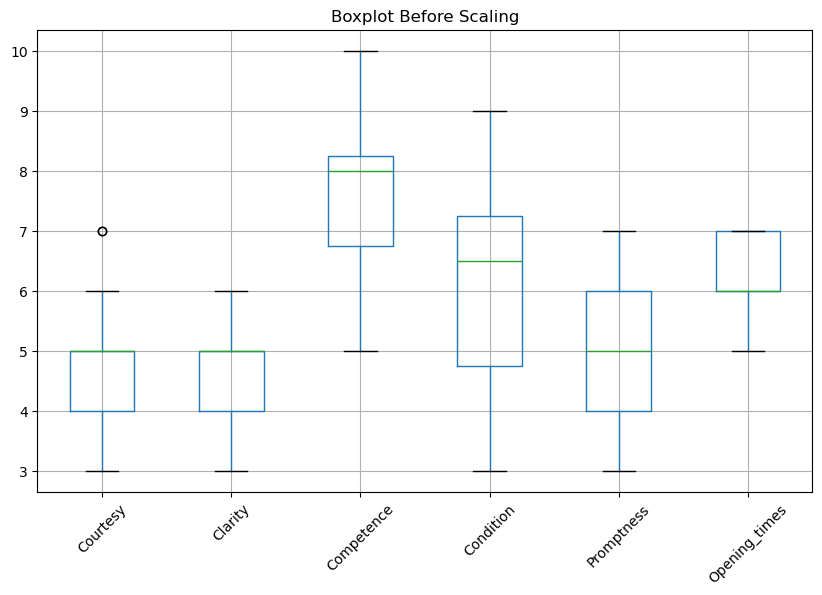

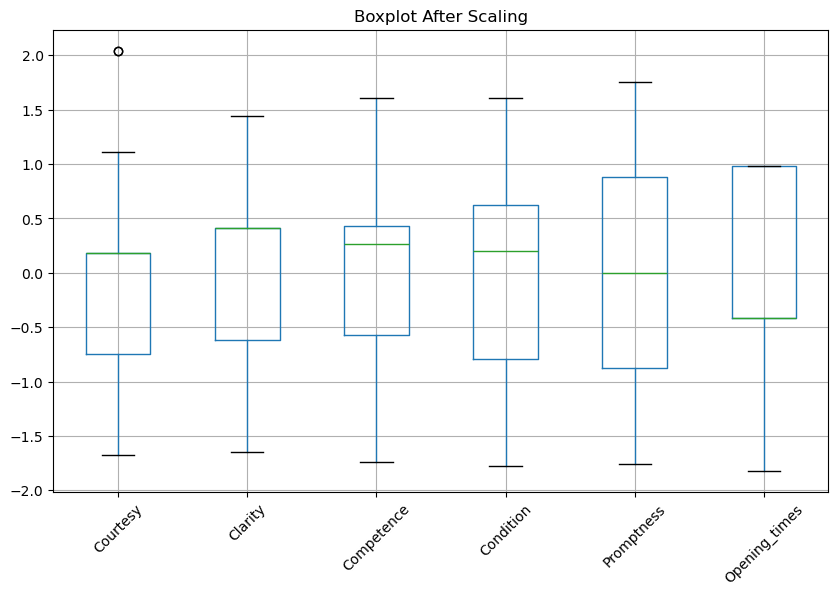

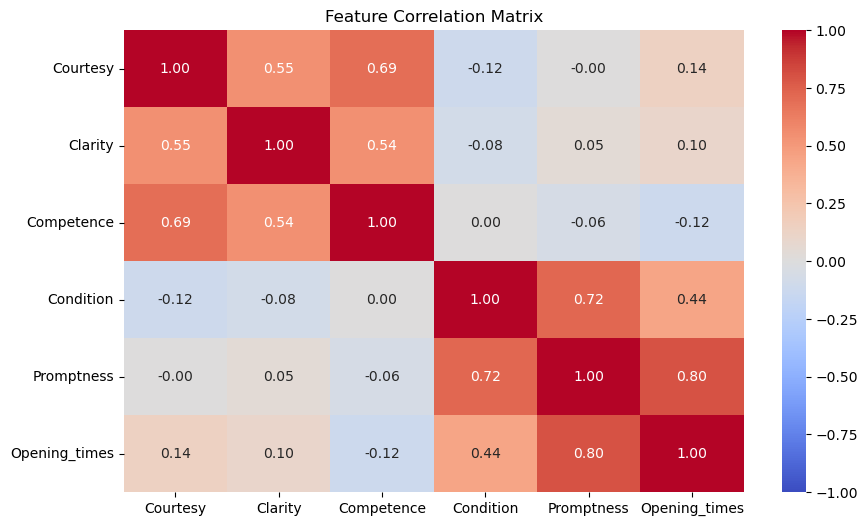

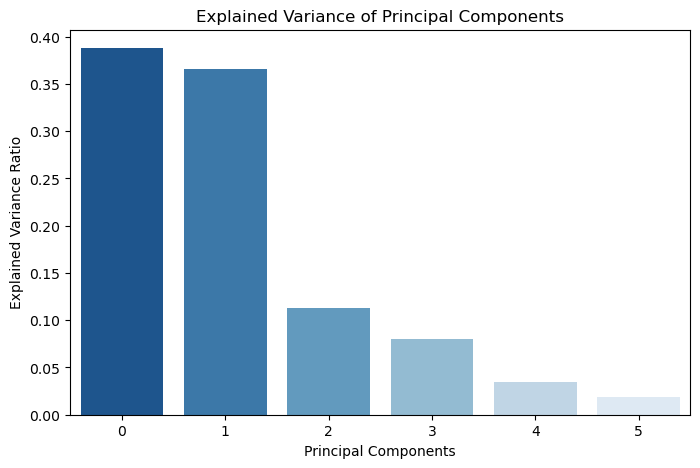

Cumulative Explained Variance:
           0        1         2         3         4    5
0  0.387939  0.75417  0.866903  0.947328  0.981563  1.0
PCA Component Loadings:
      Courtesy   Clarity  Competence  Condition  Promptness  Opening_times
PC1  0.108588  0.082955    0.166297  -0.527831   -0.616793      -0.542802
PC2 -0.586905 -0.538902   -0.562070  -0.051455   -0.135631      -0.167814
PC3 -0.123933 -0.244882    0.467594   0.651152   -0.018854      -0.530731
PC4  0.537682 -0.790670    0.155511  -0.143601   -0.023690       0.200931
PC5  0.545638  0.131997   -0.617261   0.443239   -0.274763      -0.178578
PC6  0.203886 -0.012432   -0.180513  -0.278686    0.724403      -0.568564


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Load the dataset
df2 = pd.read_csv("csat.csv")

# Step 2: Visualize data before scaling
plt.figure(figsize=(10, 6))
df2.boxplot(rot=45)
plt.title("Boxplot Before Scaling")
plt.show()

# Step 3: Standardize the dataset
scaler = StandardScaler()
df2_scaled = pd.DataFrame(scaler.fit_transform(df2.astype(float)), columns=df2.columns)

# Step 4: Visualize data after scaling
plt.figure(figsize=(10, 6))
df2_scaled.boxplot(rot=45)
plt.title("Boxplot After Scaling")
plt.show()

# Step 5: Compute and visualize the correlation matrix
corr = df2.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

# Step 6: Apply PCA
pca = PCA(n_components=6)  # Adjust based on the dataset
df2_pca = pd.DataFrame(pca.fit_transform(df2_scaled))

# Step 7: Analyze Explained Variance
explained_var = pd.DataFrame(pca.explained_variance_ratio_).transpose()
plt.figure(figsize=(8, 5))
sns.barplot(data=explained_var, palette="Blues_r")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance of Principal Components")
plt.show()

# Step 8: Compute Cumulative Explained Variance
cum_explained_var = np.cumsum(pca.explained_variance_ratio_)
cum_explained_var_df = pd.DataFrame(cum_explained_var).transpose()
print("Cumulative Explained Variance:\n", cum_explained_var_df)

# Step 9: Analyze PCA Component Loadings
pca_components = pd.DataFrame(pca.components_, index=[f'PC{i+1}' for i in range(pca.n_components_)], columns=df2.columns)
print("PCA Component Loadings:\n", pca_components)

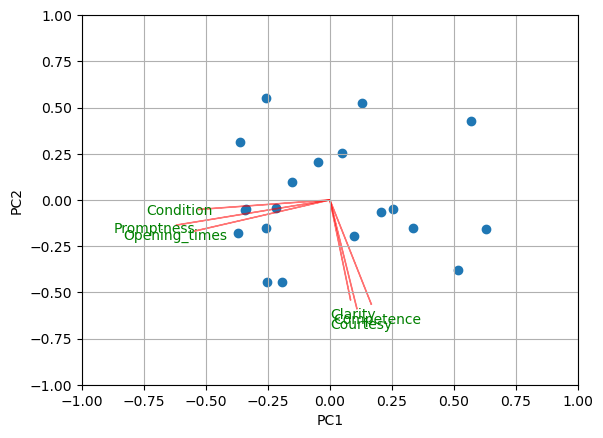

In [17]:
def myplot(score,coeff,labels=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    plt.scatter(xs * scalex,ys * scaley)
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1],color = 'r',alpha = 0.5)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')
    plt.xlim(-1,1)
    plt.ylim(-1,1)
    plt.xlabel("PC{}".format(1))
    plt.ylabel("PC{}".format(2))
    plt.grid()
    plt.show()

#Call the function. Use only the 2 PCs.
myplot(pca.transform(df2_scaled)[:,0:2],np.transpose(pca.components_[0:2, :]), df2.columns)

**1st component**:

The variables

   - Condition
   - Promptness
   - Opening-times

show a high correlation with the first component. This component can be summarized as an index of the **structure’s performances**

**2nd component**:

The variables
   - Courtesy
   - Clarity
   - Competence

show a high correlation with the second component. 
This component can be summarized as an index of the **personnel’s performance**

**Notice that the Principal Components have negative values in the variables that they explain.**

In [21]:
df2_pca.columns=['PC1','PC2','PC3','PC4','PC5','PC6']
df2_pca

,PC1,PC2,PC3,PC4,PC5,PC6
0,-1.213592,-2.284217,0.227626,0.943510,0.639256,0.028990
1,1.595084,-0.785365,-0.803792,-0.889361,-0.095906,-0.086024
2,-1.768841,-0.908673,-0.239397,-0.098422,-0.453160,0.563923
3,-0.930384,-2.266028,-0.278082,-0.290028,0.018155,-0.015550
4,2.474352,-1.951528,-0.139969,1.153190,0.197307,-0.571159
5,0.983820,-0.337580,-0.430245,1.220114,-0.102566,0.764267
6,3.007233,-0.806971,0.268340,-1.046038,-0.017288,-0.045829
7,1.211056,-0.258626,-0.183017,-0.155048,0.018583,-0.230788
8,-0.224336,1.040537,0.592068,-0.125843,0.048535,0.033514
9,-1.227878,-0.789717,-0.222861,-0.077645,-0.212176,-0.071421


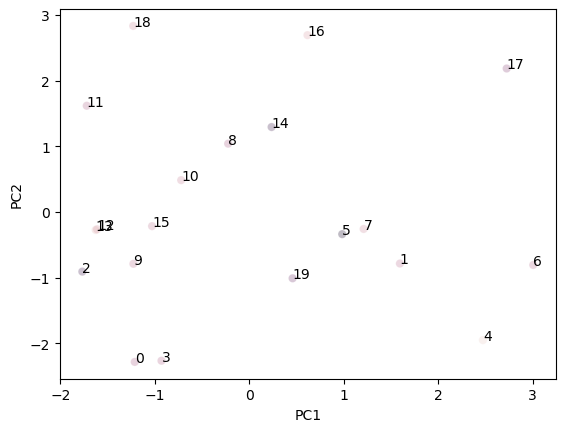

In [23]:
p1=sns.scatterplot(x="PC1", y="PC2",
              alpha=.3, 
              hue="PC6", legend=False,
              data=df2_pca);

# add annotations one by one with a loop
for line in range(0,df2_pca.shape[0]):
     p1.text(df2_pca.PC1[line], df2_pca.PC2[line], line, horizontalalignment='left', size='medium', color='black')


We conclude that 
 - centers 18,11 has a GOOD infrastructure but a BAD service
 - the group near 1,4,6 has BAD infrastructure but GOOD service quality 
 - the group 0,3,2,9 has GOOD infrastructure and service
 - center 17 has BAD infrastructure and service!

# MTCARS

The car types are a mix that includes sedans (Datsun, Ford, Honda,…), luxury sedans (Mercedes, Cadellac,..), muscle cars (Javelin, Challenger, Camaro…) and high-end sports cars (Porsche, Lotus, Maserati, Ferrari…)

- 	mpg 	Miles/US Gallon 	mpg is the determinant of fuel efficiency
- 	cyl 	Number of cylinders 	Data includes vehicles with 4,6,8 cylinder engines.
- 	disp 	Displacement (cu.in.) 	Displacement measures overall volume in the engine as a factor of cylinder circumfrance, depth and total number of cylinders. This metric gives a good proxy for the total amount of power the engine can generate.
- 	hp 	Gross horsepower 	Gross horsepower measures the theoretical output of an engine’s power output
- 	drat 	Rear axle ratio 	The rear axle gear ratio indicates the number of turns of the drive shaft for every one rotation of the wheel axle. 
-   wt      weigth of the car 
- 	qsec 	1/4 mile time 	A performance measure, primarily of acceleration. Fastest time to travel 1/4 mile from standstill (in seconds).
- 	vs 	V/S 	Binary variable signaling the engine cylinder configuration a V-shape (vs=0) or Straight Line (vs=1). V==0 and S==1. 
- 	am 	Transmission Type 	A binary variable signaling whether vehicle has automatic (am=0) or manual (am=1) transmission configuration.
- 	gear 	Number of forward gears 	Number of gears in the transmission.
- 	carb 	Number of carburetors 	The number of carburetor barrels.

<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **Exercise - PCA on the `mtcars` Dataset: Standardization & Principal Component Analysis**

#### **Objective**
- Apply **Principal Component Analysis (PCA)** to the **`mtcars` dataset**.
- Standardize the dataset using **StandardScaler**.
- Compute and interpret **principal components**.
- Visualize how the dataset changes after **PCA transformation**.

---

#### **Instructions**
1. **Load and Inspect the Dataset**:
   - Read the `mtcars.csv` dataset into a Pandas DataFrame.
   - Display the first few rows to understand the structure.

2. **Standardize the Data**:
   - Use `StandardScaler()` to normalize the dataset.
   - Generate a **boxplot before and after scaling** to observe changes.

3. **Apply PCA to the Standardized Data**:
   - Fit PCA to the standardized dataset.
   - Extract and print **principal components**.

4. **Visualize Principal Component Loadings**:
   - Display how the original features contribute to the principal components.

5. **Analyze Explained Variance**:
   - Compute **explained variance ratio** for each principal component.
   - Plot the **cumulative explained variance** to determine the optimal number of components.

---

Dataset Overview:
                     mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
Mazda RX4          21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
Mazda RX4 Wag      21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
Datsun 710         22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
Hornet 4 Drive     21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   

                   carb  
Mazda RX4             4  
Mazda RX4 Wag         4  
Datsun 710            1  
Hornet 4 Drive        1  
Hornet Sportabout     2  


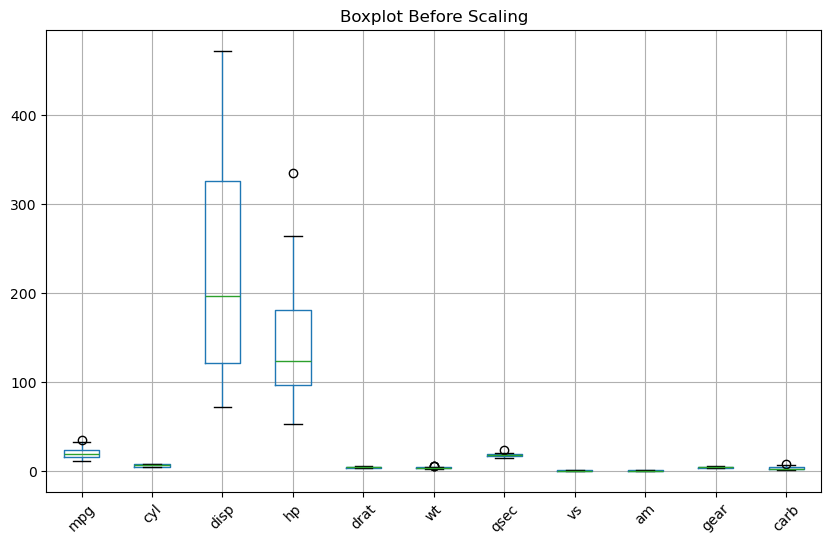

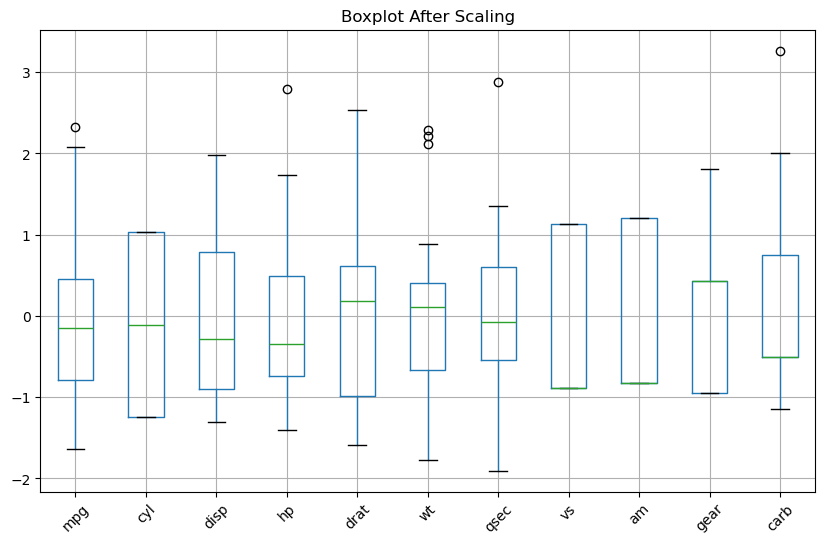


Principal Component Loadings:
            mpg       cyl      disp        hp      drat        wt      qsec  \
PC1   0.362531 -0.373916 -0.368185 -0.330057  0.294151 -0.346103  0.200456   
PC2   0.016124  0.043744 -0.049324  0.248784  0.274694 -0.143038 -0.463375   
PC3  -0.225744 -0.175311 -0.061484  0.140015  0.161189  0.341819  0.403169   
PC4  -0.022540 -0.002592  0.256608 -0.067676  0.854829  0.245899  0.068077   
PC5   0.102845  0.058484  0.393995  0.540047  0.077327 -0.075029 -0.164666   
PC6  -0.108797  0.168554 -0.336165  0.071436  0.244497 -0.464940 -0.330480   
PC7   0.367724  0.057278  0.214303 -0.001496  0.021120 -0.020668  0.050011   
PC8   0.754091  0.230825 -0.001142  0.222358 -0.032194  0.008572  0.231840   
PC9  -0.235702 -0.054035 -0.198428  0.575830  0.046901 -0.359498  0.528377   
PC10  0.139285 -0.846419  0.049380  0.247824 -0.101494  0.094394 -0.270673   
PC11  0.124896  0.140695 -0.660606  0.256492  0.039530  0.567449 -0.181362   

            vs        am      g

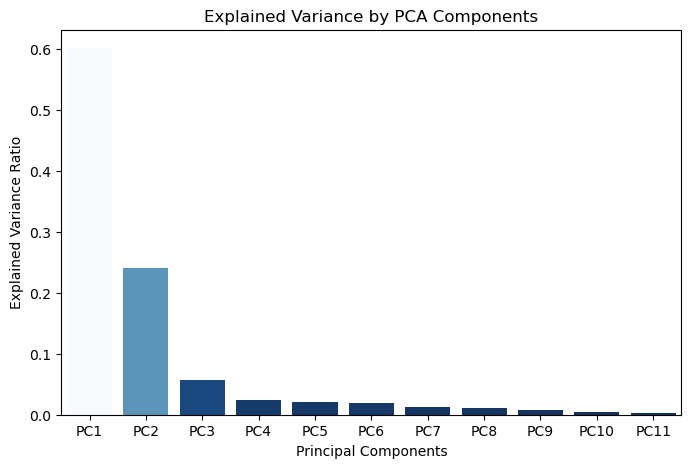

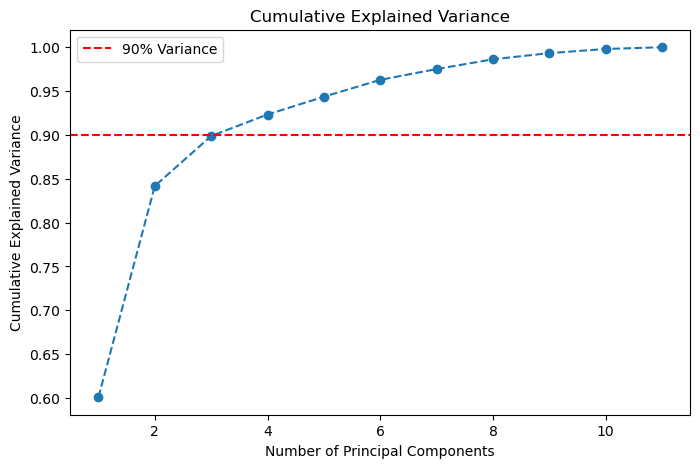

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Load the dataset
cars = pd.read_csv('mtcars.csv', index_col=0)
print("Dataset Overview:\n", cars.head())

# Step 2: Visualize data before scaling
plt.figure(figsize=(10, 6))
cars.boxplot(rot=45)
plt.title("Boxplot Before Scaling")
plt.show()

# Step 3: Standardize the dataset
scaler = StandardScaler()
df_cars = pd.DataFrame(scaler.fit_transform(cars.astype(float)), columns=cars.columns)

# Step 4: Visualize data after scaling
plt.figure(figsize=(10, 6))
df_cars.boxplot(rot=45)
plt.title("Boxplot After Scaling")
plt.show()

# Step 5: Apply PCA
pca = PCA()
df_cars_pca = pca.fit_transform(df_cars)

# Step 6: Display Principal Components
pca_components = pd.DataFrame(pca.components_, columns=cars.columns, index=[f'PC{i+1}' for i in range(pca.n_components_)])
print("\nPrincipal Component Loadings:\n", pca_components)

# Step 7: Analyze Explained Variance
explained_variance_ratio = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=[f'PC{i+1}' for i in range(len(explained_variance_ratio))], 
    y=explained_variance_ratio, 
    hue=explained_variance_ratio,  # Explicitly set hue to None
    palette="Blues_r",
    legend=False  # Ensure no unwanted legend is created
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by PCA Components")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker="o", linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.axhline(y=0.90, color='r', linestyle="--", label="90% Variance")
plt.legend()
plt.show()



In [45]:
cars_pca = pd.DataFrame(pca.transform(df_cars),columns = ['pc1', 'pc2','pc3','pc4','pc5', 'pc6','pc7','pc8','pc9','pc10','pc11']
                        ,index=cars.index.values)
cars_pca.head()

,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9,pc10,pc11
Mazda RX4,0.657213,1.735446,-0.601199,0.115522,-0.960653,-0.017259,-0.433311,0.009785,-0.148766,-0.067771,-0.182569
Mazda RX4 Wag,0.629396,1.550033,-0.382322,0.202307,-1.032949,-0.245592,-0.422860,0.085873,-0.075721,-0.128959,-0.090063
Datsun 710,2.779397,-0.146457,-0.241238,-0.249139,0.405143,-0.354348,-0.618584,-0.594620,0.133328,0.046470,0.096147
Hornet 4 Drive,0.311771,-2.363019,-0.135759,-0.511862,0.557997,0.019606,-0.041007,0.050376,-0.223742,-0.061366,-0.149973
Hornet Sportabout,-1.974489,-0.754402,-1.134402,0.075653,0.210836,0.151580,0.389645,0.162863,0.021515,-0.060787,-0.148750


/var/folders/mn/rzjlcs791970gbxf6my2jtpw0000gp/T/ipykernel_60957/2031328931.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p2.text(cars_pca.pc1[line], cars_pca.pc2[line], cars_pca.index[line], horizontalalignment='left', size='medium', color='black')


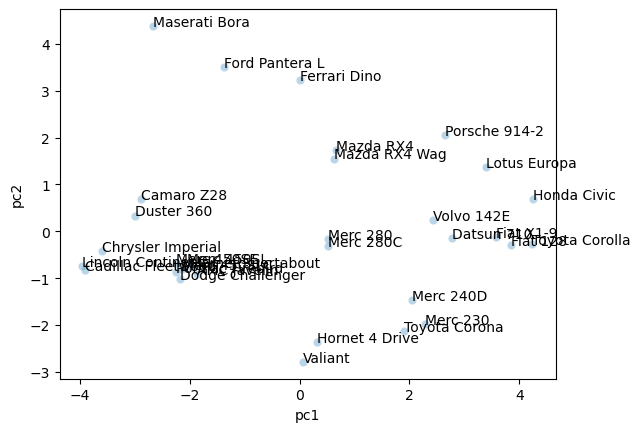

In [49]:
p2=sns.scatterplot(x="pc1", y="pc2",
              alpha=.3,
              data=cars_pca);
# add annotations one by one with a loop
for line in range(0,cars_pca.shape[0]):
     p2.text(cars_pca.pc1[line], cars_pca.pc2[line], cars_pca.index[line], horizontalalignment='left', size='medium', color='black')

# Iris database

<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **Exercise - PCA on the Iris Dataset: Standardization & Dimensionality Reduction**

#### **Objective**
- Apply **Principal Component Analysis (PCA)** to the **Iris dataset**.
- Standardize the dataset using **StandardScaler**.
- Compute and interpret **principal components**.
- Visualize the **explained variance** and **PCA-transformed data**.

---

#### **Instructions**
1. **Load and Inspect the Iris Dataset**:
   - Load the Iris dataset from `sklearn.datasets`.
   - Convert it into a Pandas DataFrame with proper column names.

2. **Standardize the Data**:
   - Use `StandardScaler()` to normalize the dataset.
   - Generate a **boxplot before and after scaling** to observe changes.

3. **Apply PCA to the Standardized Data**:
   - Fit PCA to the scaled dataset.
   - Extract and print **principal components**.

4. **Visualize Explained Variance**:
   - Create a **bar plot** of explained variance to determine important components.

5. **Project Data onto the First Two Principal Components**:
   - Transform the dataset using the **top 2 principal components**.
   - Plot the **PCA scatter plots** to observe clustering.

---

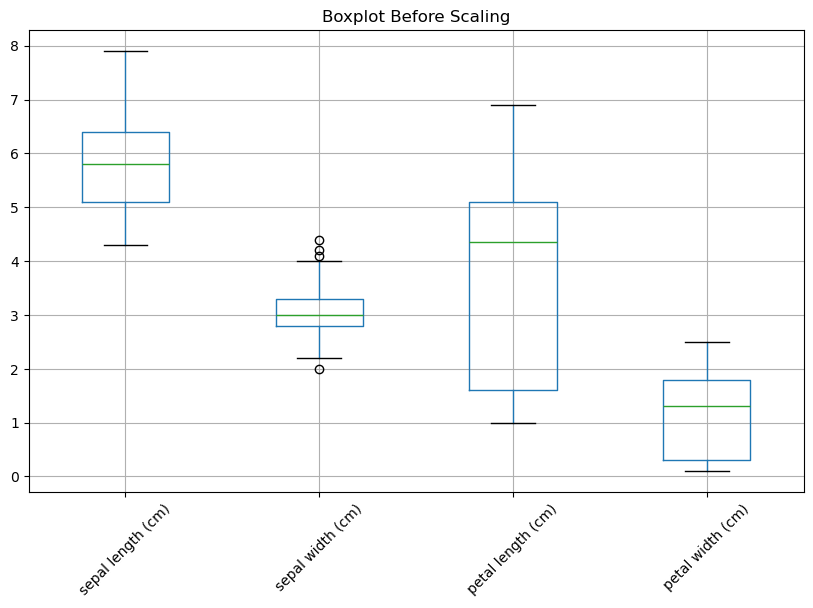

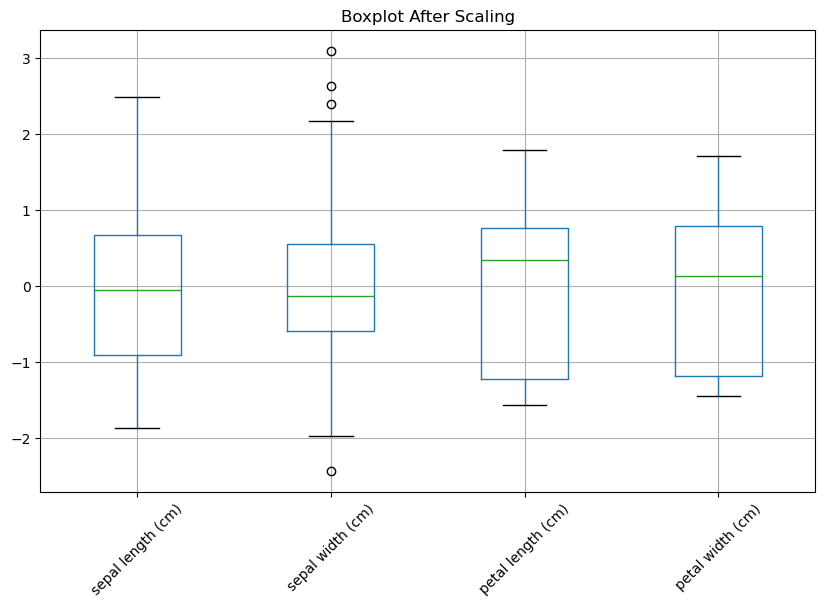

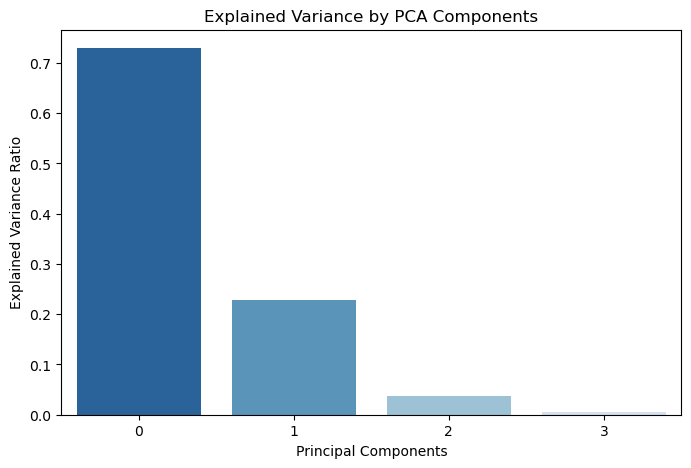

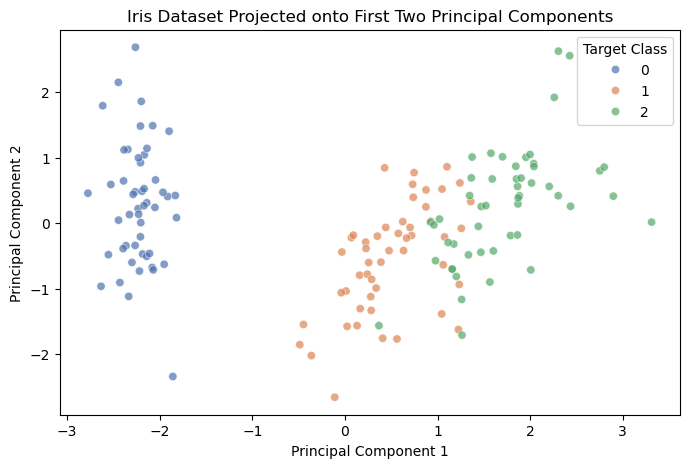

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

# Step 1: Load the Iris Dataset
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Step 2: Visualize data before scaling
plt.figure(figsize=(10, 6))
iris_df.boxplot(rot=45)
plt.title("Boxplot Before Scaling")
plt.show()

# Step 3: Standardize the dataset
scaler = StandardScaler()
iris_scaled = pd.DataFrame(scaler.fit_transform(iris_df), columns=iris_df.columns)

# Step 4: Visualize data after scaling
plt.figure(figsize=(10, 6))
iris_scaled.boxplot(rot=45)
plt.title("Boxplot After Scaling")
plt.show()

# Step 5: Apply PCA
pca = PCA()
pca.fit(iris_scaled)

# Step 6: Analyze Explained Variance
explained_variance_ratio = pd.DataFrame(pca.explained_variance_ratio_).transpose()
plt.figure(figsize=(8, 5))
sns.barplot(data=explained_variance_ratio, palette="Blues_r")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by PCA Components")
plt.show()

# Step 7: Transform Data Using PCA
iris_pca = pd.DataFrame(pca.transform(iris_scaled), columns=['PC1', 'PC2', 'PC3', 'PC4'])

# Step 8: Visualize the PCA Projection
plt.figure(figsize=(8, 5))
sns.scatterplot(x="PC1", y="PC2", hue=iris['target'], alpha=0.7, data=iris_pca, palette="deep")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset Projected onto First Two Principal Components")
plt.legend(title="Target Class")
plt.show()
